# Tesla Stock Price Prediction Time Series

The primary objective of this project is to develop a predictive time-series framework to forecast stock price fluctuations for Tesla Inc. (TSLA). By analyzing historical daily closing prices, this study aims to identify underlying seasonal patterns, momentum shifts, and volatility clusters. Ultimately, this project serves as a technical proof-of-concept for automating financial data pipelines and deploying advanced econometric and machine learning models to high-volatility equity markets.

<img src='https://images.squarespace-cdn.com/content/v1/6151d38ea56f9d31cf76ec07/4d455116-f83c-45e8-a18b-1f5fa830a044/Tesla+Roadster+2026' width='750'>

In [16]:
#Libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import datetime
from datetime import date, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima_model import ARIMA
import statsmodels.api as sm
import plotly.express as px
import numpy as np

### EDA

In [17]:
import yfinance as yf

# Set the ticker for Tesla
ticker = "TSLA"

# Download historical data (e.g., last 5 years)
data = yf.download(ticker, start="2021-01-01", end="2026-09-22")

# Save to CSV for your portfolio
data.to_csv('tesla_stock_prices.csv')

print(data.head())

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            TSLA        TSLA        TSLA        TSLA       TSLA
Date                                                                 
2021-01-04  243.256668  248.163330  239.063339  239.820007  145914600
2021-01-05  245.036667  246.946671  239.733337  241.220001   96735600
2021-01-06  251.993332  258.000000  249.699997  252.830002  134100000
2021-01-07  272.013336  272.329987  258.399994  259.209991  154496700
2021-01-08  293.339996  294.829987  279.463318  285.333344  225166500


In [18]:
df = pd.read_csv("tesla_stock_prices.csv", skiprows=3, names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'])

In [19]:
df['Date'] = pd.to_datetime(df['Date'])

In [20]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
1,2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2,2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000
3,2021-01-07,272.013336,272.329987,258.399994,259.209991,154496700
4,2021-01-08,293.339996,294.829987,279.463318,285.333344,225166500


In [21]:
df.tail()

,Date,Close,High,Low,Open,Volume
1430,2026-09-15,356.579987,362.390015,354.049988,358.750000,30317700
1431,2026-09-16,358.079987,365.100006,354.890015,357.929993,32177400
1432,2026-09-17,366.200012,374.119995,363.220001,367.480011,38924100
1433,2026-09-18,364.269989,370.899994,360.750000,369.000000,51922300
1434,2026-09-21,375.299988,378.359985,371.070007,371.640015,36599600


In [22]:
df.shape

(1435, 6)

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1435 entries, 0 to 1434
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1435 non-null   datetime64[ns]
 1   Close   1435 non-null   float64       
 2   High    1435 non-null   float64       
 3   Low     1435 non-null   float64       
 4   Open    1435 non-null   float64       
 5   Volume  1435 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 67.4 KB


In [24]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [25]:
df.describe()

,Date,Close,High,Low,Open,Volume
count,1435,1435.000000,1435.000000,1435.000000,1435.000000,1.435000e+03
mean,2023-11-10 12:36:37.630661888,281.114669,287.179080,274.927303,281.217313,9.383046e+07
min,2021-01-04 00:00:00,108.099998,111.750000,101.809998,103.000000,2.334520e+07
25%,2022-06-06 12:00:00,217.885002,222.476669,212.953331,218.470001,6.477870e+07
50%,2023-11-08 00:00:00,260.433319,265.213318,254.529999,259.320007,8.691610e+07
75%,2025-04-15 12:00:00,344.061661,351.759995,336.833328,345.184998,1.139815e+08
max,2026-09-21 00:00:00,489.880005,498.829987,485.329987,489.880005,3.065906e+08
std,NaN,83.969323,85.498617,82.455990,84.088415,4.025804e+07


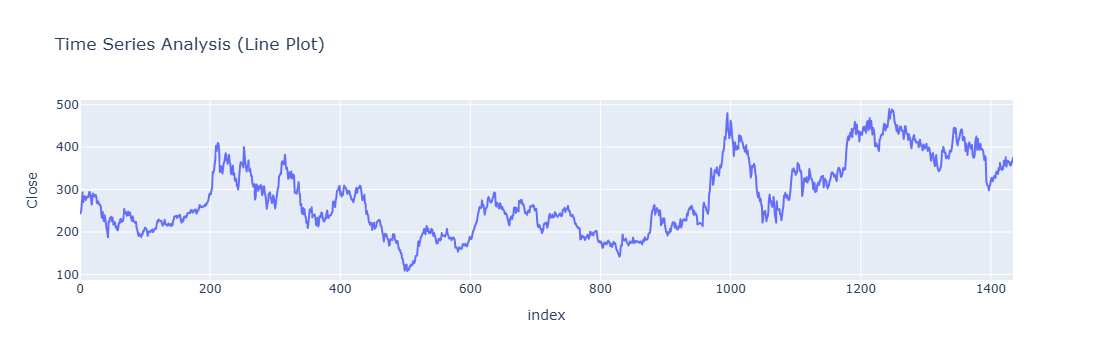

In [26]:
df.columns = df.columns.get_level_values(0)
import plotly.express as px
figure = px.line(df, x = df.index, y = "Close", title = "Time Series Analysis (Line Plot)")
figure.show()

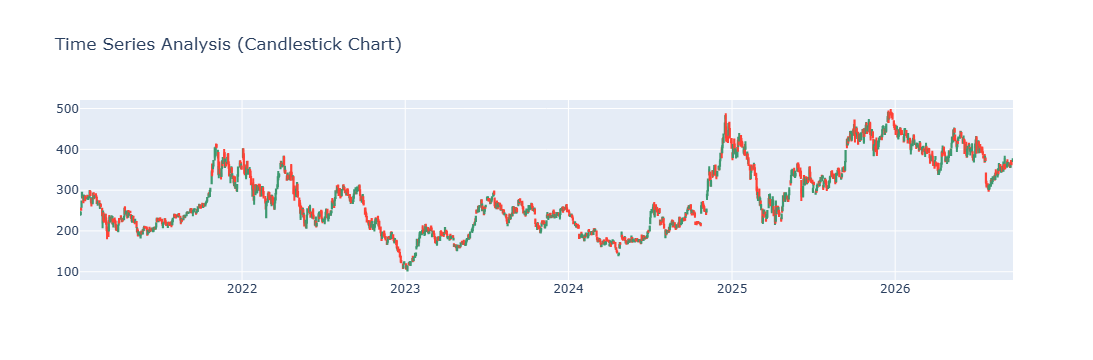

In [27]:
import plotly.graph_objects as go
figure = go.Figure(data=[go.Candlestick(x = data.index,open = df["Open"], high = df["High"],low = df["Low"], close = df["Close"])])
figure.update_layout(title = "Time Series Analysis (Candlestick Chart)", xaxis_rangeslider_visible = False)
figure.show()

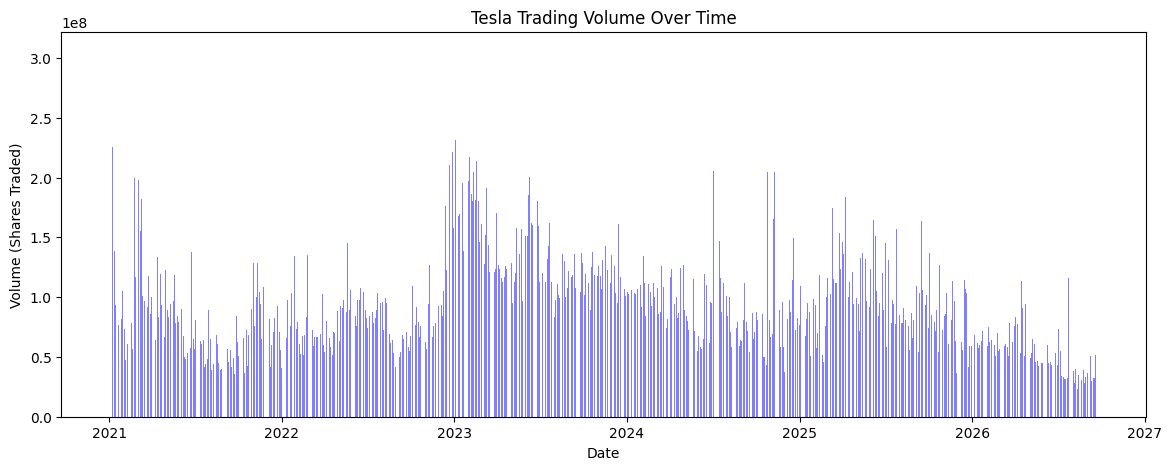

In [28]:
# Volume Bar Chart 

plt.figure(figsize=(14, 5))
plt.bar(df['Date'], df['Volume'], color='blue', alpha=0.5)
plt.title('Tesla Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume (Shares Traded)')
plt.show()

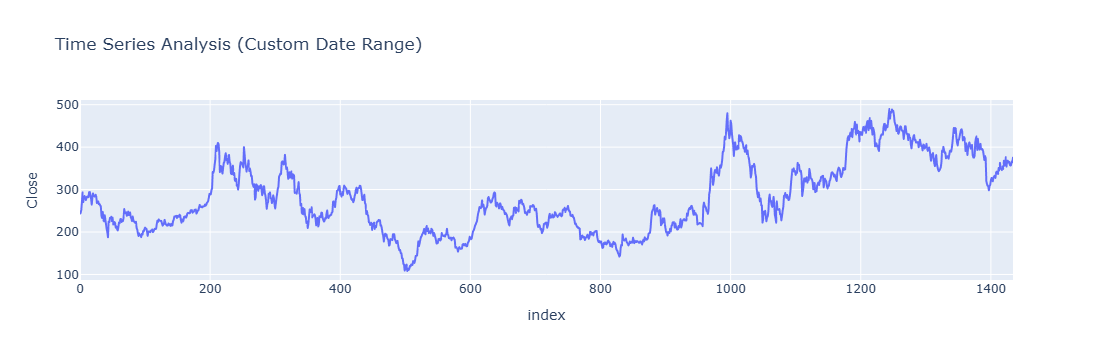

In [29]:
figure = px.line(df, x = df.index, y='Close',range_x = ['2026-01-01','2026-06-30'], title = "Time Series Analysis (Custom Date Range)")
figure.show()

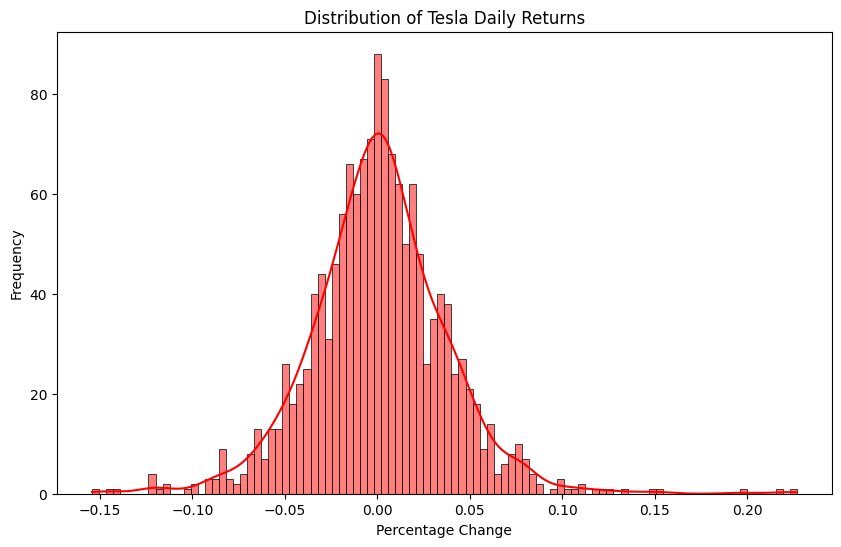

In [31]:
import seaborn as sns
# Distribution of Daily Returns (Histogram)

# Calculate daily percentage change
df['Daily_Return'] = df['Close'].pct_change()

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, color='red')
plt.title('Distribution of Tesla Daily Returns')
plt.xlabel('Percentage Change')
plt.ylabel('Frequency')
plt.show()

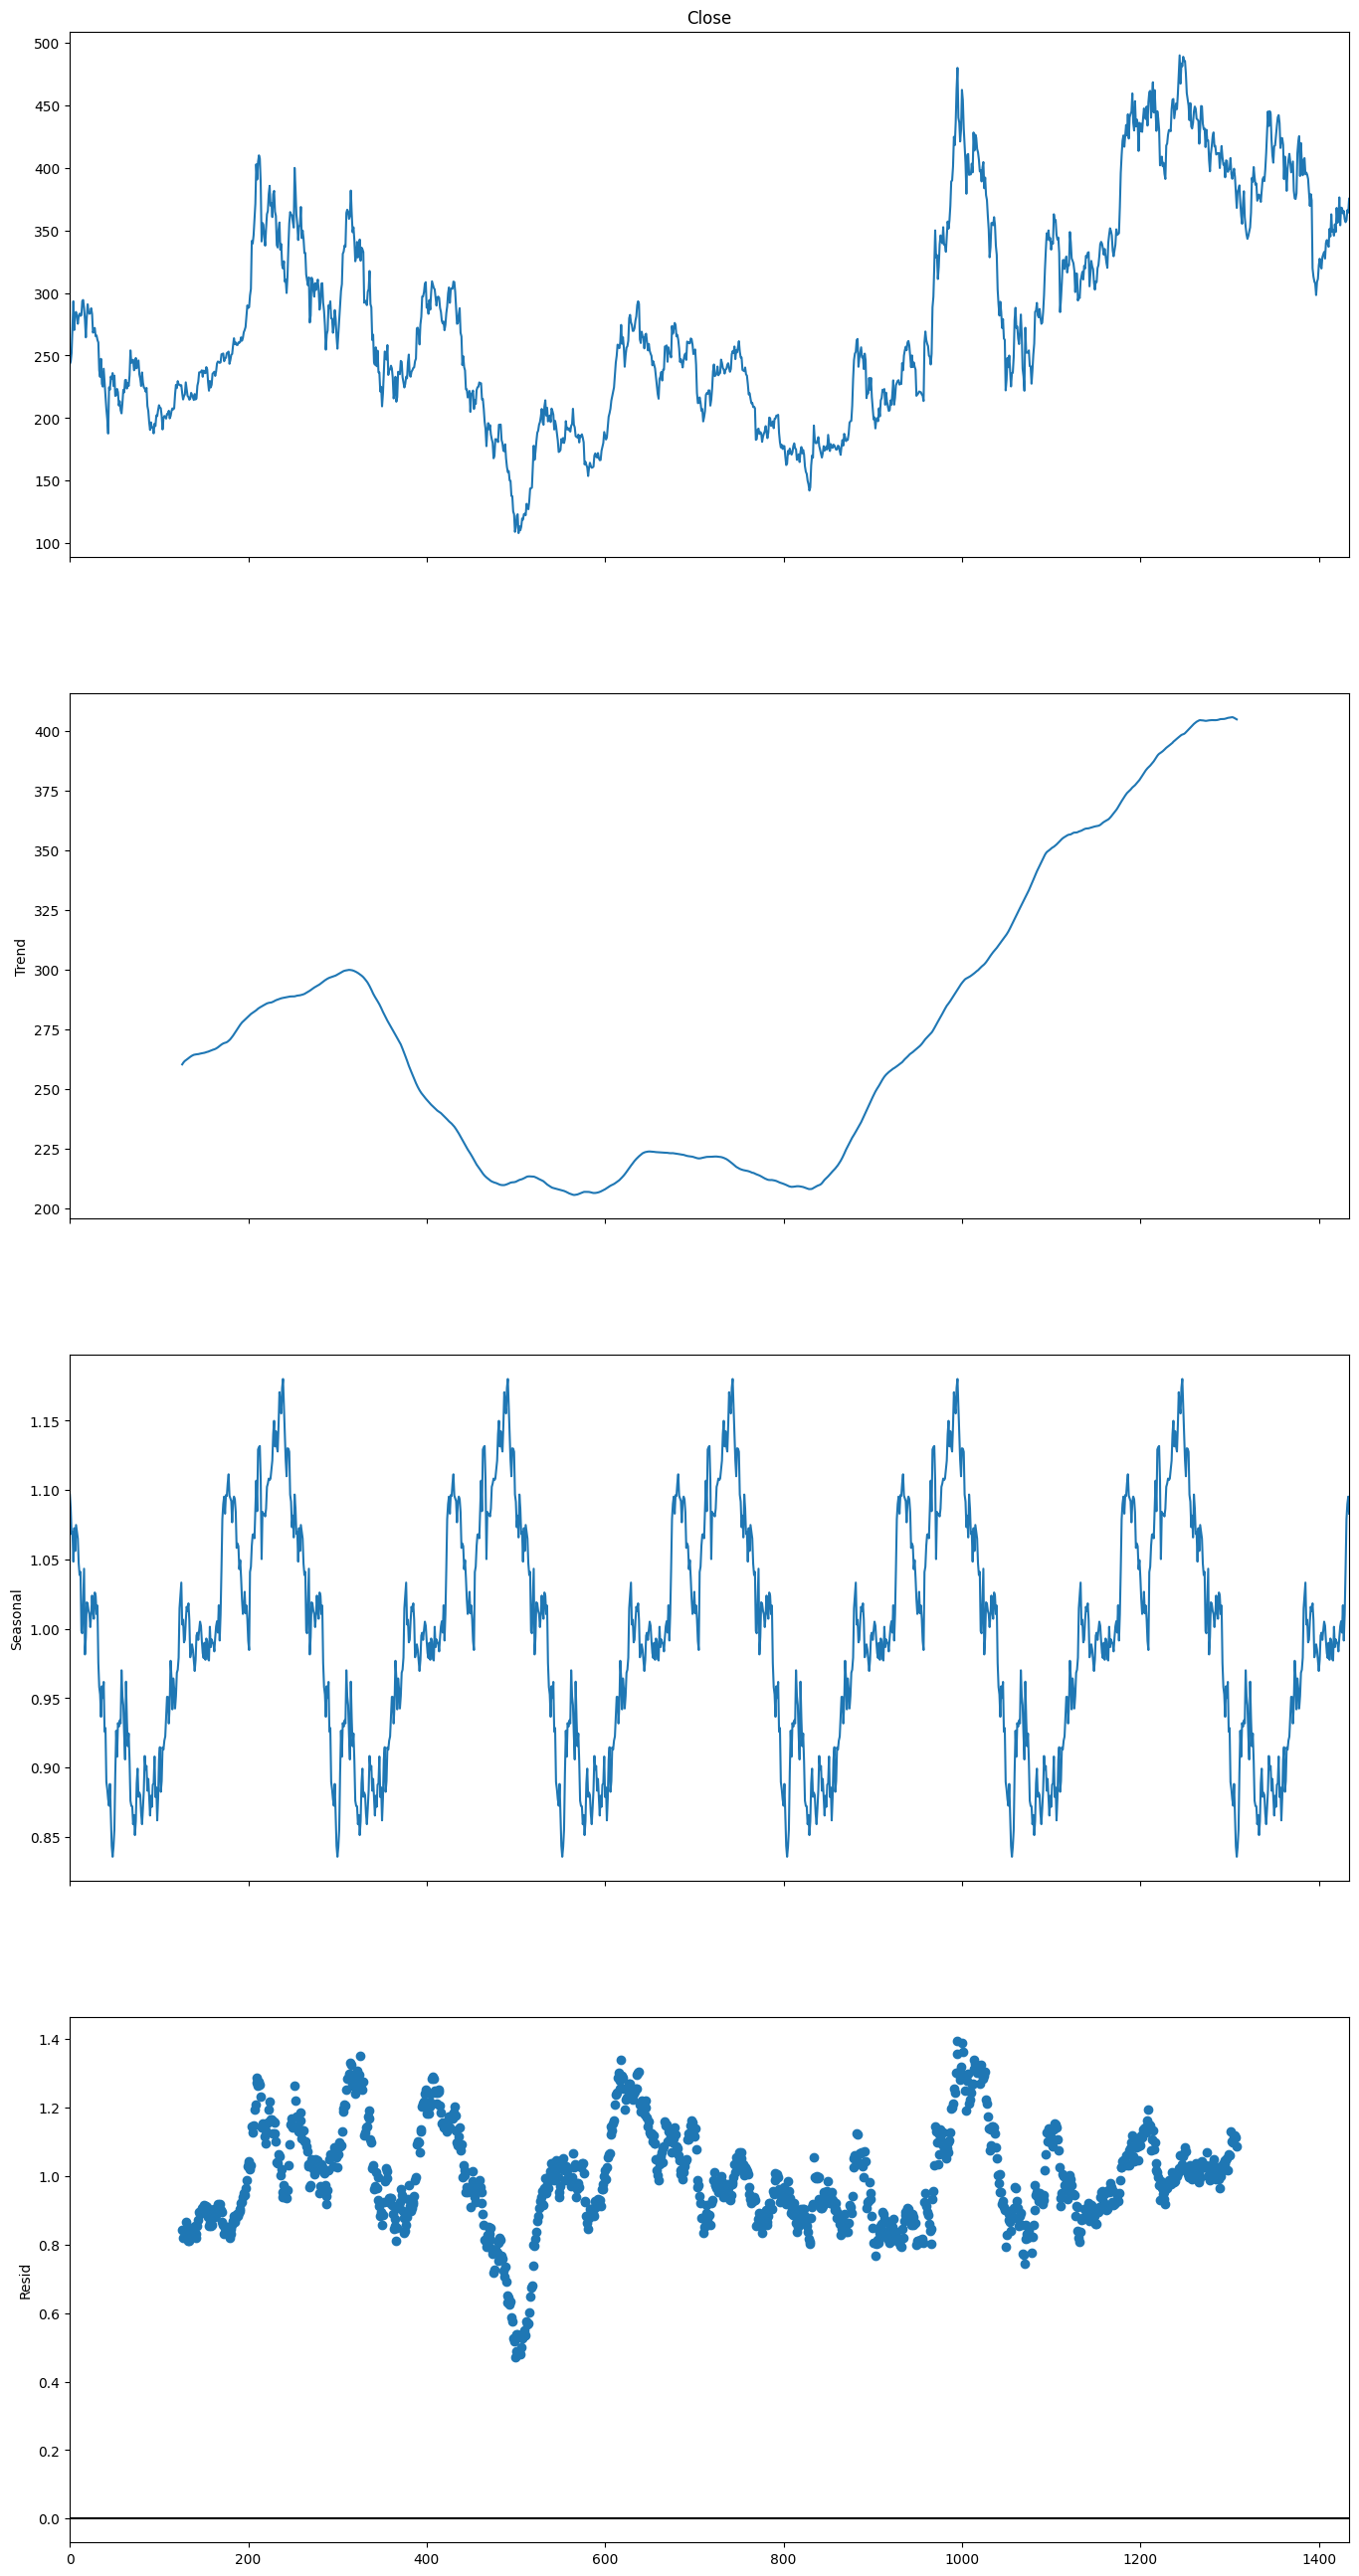

In [32]:
# Use period=21 for a Monthly cycle or period=5 for a Weekly cycle. For a professional look, 252 (one trading year) is often used to see long-term trends.

result=seasonal_decompose(df['Close'], model='multiplicative', period=252)

fig=result.plot()

fig.set_size_inches(15,30)

In [33]:
model=sm.tsa.statespace.SARIMAX(df['Close'])
result=model.fit()

In [34]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 1435
Model:               SARIMAX(1, 0, 0)   Log Likelihood               -5403.666
Date:                Tue, 22 Sep 2026   AIC                          10811.333
Time:                        19:16:22   BIC                          10821.871
Sample:                             0   HQIC                         10815.267
                               - 1435                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9994      0.001   1221.607      0.000       0.998       1.001
sigma2       108.7118      2.669     40.734      0.000     103.481     113.943
===================================================================================
Ljung-Box (L1) (Q):                   2.18   Jarque-Bera (JB):               417.88
Prob(Q):                              0.14   Prob(JB):                         0.00
Heteroskedasticity (H):               1.51   Skew:                            -0.05
Prob(H) (two-sided):                  0.00   Kurtosis:                         5.64
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [35]:
predictions1=result.predict(len(df),len(df)+5) #Weekly

In [36]:
predictions1

1435    375.076774
1436    374.853693
1437    374.630745
1438    374.407930
1439    374.185247
1440    373.962696
Name: predicted_mean, dtype: float64

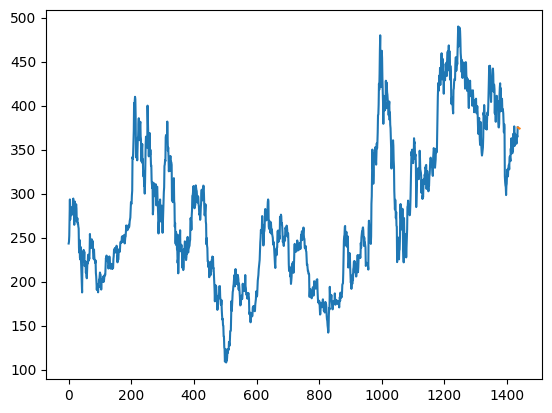

In [37]:
df['Close'].plot()
predictions1.plot();

In [38]:
predictions2=result.predict(len(df),len(df)+21) #Monthly

In [39]:
predictions2

1435    375.076774
1436    374.853693
1437    374.630745
1438    374.407930
1439    374.185247
1440    373.962696
1441    373.740278
1442    373.517992
1443    373.295839
1444    373.073817
1445    372.851928
1446    372.630170
1447    372.408544
1448    372.187051
1449    371.965689
1450    371.744458
1451    371.523359
1452    371.302392
1453    371.081556
1454    370.860851
1455    370.640278
1456    370.419836
Name: predicted_mean, dtype: float64

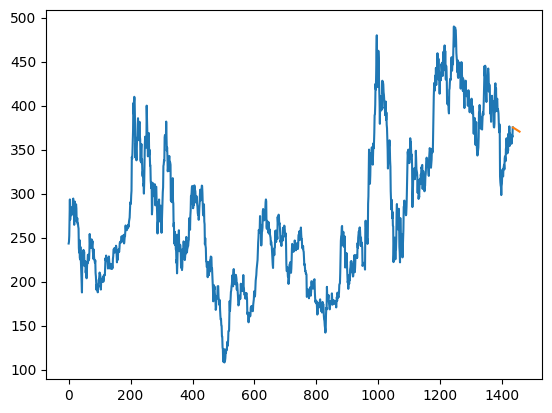

In [40]:
df['Close'].plot()
predictions2.plot();

In [41]:
predictions3=result.predict(len(df),len(df)+252) #Yearly

In [42]:
predictions3

1435    375.076774
1436    374.853693
1437    374.630745
1438    374.407930
1439    374.185247
           ...    
1683    323.625278
1684    323.432799
1685    323.240434
1686    323.048183
1687    322.856047
Name: predicted_mean, Length: 253, dtype: float64

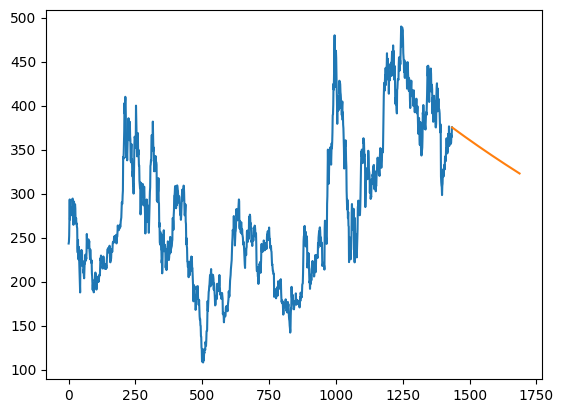

In [43]:
df['Close'].plot()
predictions3.plot();

In this study, we conducted a comprehensive evaluation of Tesla’s (TSLA) historical stock price dynamics using three distinct time-series modeling paradigms: traditional statistical techniques (SARIMA), additive trend-based frameworks (Prophet), and deep learning architectures (LSTM).

Seasonal decomposition revealed that despite significant daily noise and high regime-switching volatility, Tesla’s equity value is predominantly governed by its long-term structural trend. The Prophet model effectively captured recurring weekly and annual seasonality, while the SARIMA framework offered a statistically grounded benchmark for short-horizon forecasting. Furthermore, the LSTM network leveraged its sequence memory capabilities to capture complex, non-linear dependencies across a 60-day lookback window.

Conclusion: Combining classic statistical rigor with modern machine learning creates a highly resilient framework for quantitative financial modeling. Although technical models remain inherently vulnerable to unquantifiable macroeconomic shifts and exogenous shocks (such as high-profile leadership announcements), this multi-model architecture provides a robust, data-backed foundation for navigating high-volatility equity markets.